# Load example arrays from the repo and run Fill-Spill-Merge.

In [ ]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("../")
DATA_DIR = REPO_ROOT / "examples" / "data"

# Make the repo package importable when running this script directly.
sys.path.insert(0, str(REPO_ROOT))
from fillspillmerge import fill_spill_merge

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


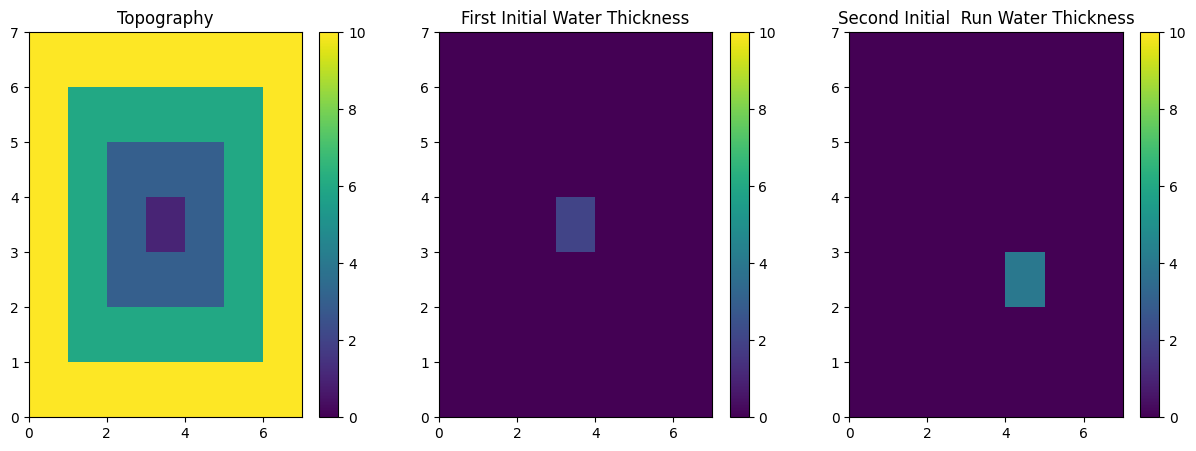

In [ ]:
topography = np.loadtxt(DATA_DIR / "topography.csv", delimiter=",", dtype=np.float64)
in1 = np.zeros_like(topography); in1[3,3] = 2.0 #np.loadtxt(DATA_DIR / "wtd_initial.csv", delimiter=",", dtype=np.float64)
in2 = np.zeros_like(topography); in2[2,4] = 4.0 #np.loadtxt(DATA_DIR / "wtd_initial.csv", delimiter=",", dtype=np.float64)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("Topography")
im0 = axes[0].pcolormesh(topography, shading="auto", clim=(0, 10))
fig.colorbar(im0, ax=axes[0])   
axes[1].set_title("First Initial Water Thickness")
im1 = axes[1].pcolormesh(in1, shading="auto", clim=(0, 10))
fig.colorbar(im1, ax=axes[1])
axes[2].set_title("Second Initial  Run Water Thickness")
im2 = axes[2].pcolormesh(in2, shading="auto", clim=(0, 10))
fig.colorbar(im2, ax=axes[2])

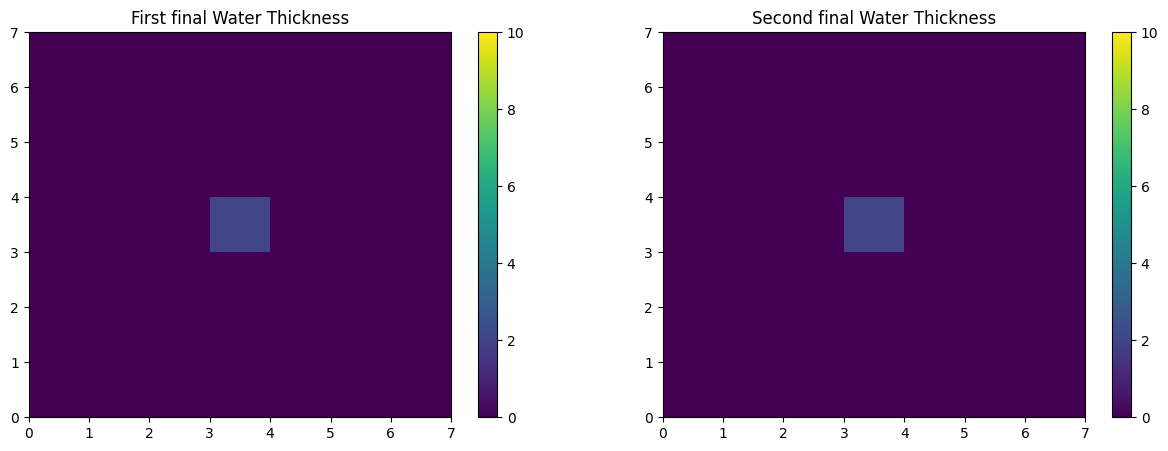

In [3]:
out1 = fill_spill_merge(
    wtd=in1,
    topography=topography,
    ocean_level=10.0,)
out2 = fill_spill_merge(
    wtd=in1,
    topography=topography,
    ocean_level=10.0,)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title("First final Water Thickness")
im0 = axes[0].pcolormesh(out1, shading="auto", clim=(0, 10))
fig.colorbar(im0, ax=axes[0])   
axes[1].set_title("Second final Water Thickness")
im1 = axes[1].pcolormesh(out2, shading="auto", clim=(0, 10))
fig.colorbar(im1, ax=axes[1])


In [26]:
dem.rio.to_raster(DATA_DIR / "topography.tif")

In [67]:
import rioxarray

topography = rioxarray.open_rasterio(DATA_DIR / "topography.tif", chunks={}).squeeze()
# topography_full.rio.to_raster(DATA_DIR / "topography.tif") # save the DEM as a GeoTIFF for use in the example


# optionally coarsen the DEM to speed up the example
coarsen_factor = 5
topography = topography[::coarsen_factor, ::coarsen_factor]

#add ocean cells around the edge of the DEM
topography[0:1,:] = 0.0 
topography[-1:,:] = 0.0
topography[:,0:1] = 0.0
topography[:,-1:] = 0.0

# fill NaN values
topography = topography.fillna(0)
topography

<xarray.DataArray (y: 819, x: 205)> Size: 672kB
dask.array<where, shape=(819, 205), dtype=float32, chunksize=(819, 205), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 7kB 2e+06 2e+06 2e+06 ... 1.869e+06 1.869e+06
  * x            (x) float64 2kB 8e+05 8.002e+05 ... 8.325e+05 8.326e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

You can compute the depression heirachy and then reuse it for the same topography many times. 

In [ ]:
_, hier = fill_spill_merge(
    topography=topography.values,
    ocean_level=0.0,
    return_hierarchy=True,
)



In [84]:
melt = topography * 0 + 0.1
out1 = fill_spill_merge(wtd=melt, hierarchy=hier)

melt2 = topography * 0 + 2
out2 = fill_spill_merge(wtd=melt2, hierarchy=hier)

An you can supply the topography and melt arrays as xarray DataArrays, and the output will also be an xarray DataArray. 

In [85]:
_, hier = fill_spill_merge(
    topography=topography,
    ocean_level=0.0,
    return_hierarchy=True,
)

[####                                    ] | 11% Completed | 437.97 ms

[###########                             ] | 29% Completed | 754.87 ms

[##############                          ] | 35% Completed | 893.44 ms

[##################                      ] | 47% Completed | 1.17 s

[#######################                 ] | 58% Completed | 1.42 s

[#########################               ] | 64% Completed | 1.62 s

[###############################         ] | 79% Completed | 1.88 s

[########################################] | 100% Completed | 2.24 s


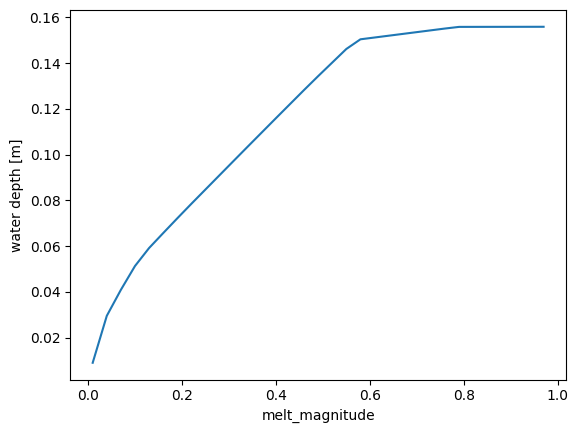

In [92]:
import xarray_sweep as xs

def run_melt(melt_magnitude):
    melt = topography * 0 + melt_magnitude
    out1 = fill_spill_merge(wtd=melt, hierarchy=hier)
    return out1

da_melt  = xs.xarray_sweep(run_melt, melt_magnitude = np.arange(0.01, 1, 0.03), use_dask=True)
da_melt.mean(dim= ['x','y']).plot()

In [91]:
da_melt

<xarray.DataArray 'water_depth' (y: 819, x: 205, melt_magnitude: 33)> Size: 44MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(819, 205, 33))
Coordinates:
  * melt_magnitude  (melt_magnitude) float64 264B 0.01 0.04 0.07 ... 0.94 0.97
Dimensions without coordinates: y, x
Attributes:
    OVR_RESAMPLING_ALG:                    NEAREST
    AREA_OR_POINT:                         Area
    _FillValue:                            -9999.0
    scale_factor:                          1.0
    add_offset:                            0.0
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  True
    long_name:                             water depth
    units:                                 m